# Decoders

In [1]:
import random
random.seed(42)

In [2]:
!pip install matplotlib tiktoken transformers torch -q

## Device

In [3]:
import torch

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Set variables

In [5]:
GPT = {
"vocab_size": 50257,
"context_length": 1024,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
}

## Set example

In [6]:
x = torch.rand(2, 4, 768)
print(f'Example shape: {x.shape}')
print(f'Example: {x}')

Example shape: torch.Size([2, 4, 768])
Example: tensor([[[0.3942, 0.0797, 0.0388,  ..., 0.7325, 0.5751, 0.1967],
         [0.4582, 0.1034, 0.1601,  ..., 0.0048, 0.1978, 0.7837],
         [0.4497, 0.5780, 0.6323,  ..., 0.7156, 0.5417, 0.6435],
         [0.3852, 0.8656, 0.6933,  ..., 0.6622, 0.6614, 0.2047]],

        [[0.6520, 0.9680, 0.4294,  ..., 0.7760, 0.3775, 0.9320],
         [0.3847, 0.0986, 0.0710,  ..., 0.9889, 0.4227, 0.4892],
         [0.4897, 0.1059, 0.1989,  ..., 0.3422, 0.1594, 0.7474],
         [0.4849, 0.2010, 0.3899,  ..., 0.2798, 0.3737, 0.3349]]])


## Self Attention Block

In [7]:
from torch import nn

In [8]:
class CausalAttention(nn.Module):
    
    def __init__(self, d_in, d_out, context_length, dropout):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        self.mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        #print(attn_weights)
        context_vec = attn_weights @ values
        return context_vec

In [9]:
attn = CausalAttention(GPT["emb_dim"], GPT["emb_dim"], GPT["context_length"], GPT["drop_rate"])
print(f'Output shape: {attn(x).shape}')
print(f'Output: {attn(x)}')

Output shape: torch.Size([2, 4, 768])
Output: tensor([[[ 0.2003,  0.3439,  0.9013,  ..., -0.4219,  0.4891,  0.3176],
         [ 0.0965,  0.4452,  0.9340,  ..., -0.2529,  0.3529,  0.4609],
         [ 0.0186,  0.4193,  0.9888,  ..., -0.2558,  0.2363,  0.4656],
         [-0.0203,  0.4955,  1.0403,  ..., -0.3685,  0.1899,  0.4032]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0178,  0.4420,  1.1964,  ..., -0.4773,  0.2180,  0.6061],
         [ 0.0180,  0.3675,  1.1443,  ..., -0.4076,  0.1729,  0.6334],
         [ 0.0079,  0.3130,  0.8160,  ..., -0.2427,  0.1495,  0.4192]]],
       grad_fn=<UnsafeViewBackward0>)


## Multi-head Attention

In [10]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_in, d_out, context_length, dropout, num_heads):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out//num_heads, context_length, dropout) for _ in range(num_heads)]
        )
        
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [11]:
mattn = MultiHeadAttention(GPT["emb_dim"], GPT["emb_dim"], GPT["context_length"], GPT["drop_rate"], GPT["n_heads"])
print(f'Output shape: {mattn(x).shape}')
print(f'Output: {mattn(x)}')

Output shape: torch.Size([2, 4, 768])
Output: tensor([[[-0.2354,  0.3420,  0.5785,  ...,  0.3013, -0.0761, -0.1132],
         [-0.2462,  0.4889,  0.4374,  ..., -0.0505,  0.0709, -0.2102],
         [-0.2491,  0.4615,  0.4420,  ..., -0.0247,  0.0780, -0.2018],
         [-0.2143,  0.4312,  0.4275,  ..., -0.0431,  0.0410, -0.1658]],

        [[-0.3701,  0.1981,  0.4873,  ..., -0.1035,  0.1080,  0.0529],
         [-0.3181,  0.2502,  0.3357,  ..., -0.1245,  0.1177,  0.0080],
         [-0.2031,  0.3004,  0.3756,  ..., -0.0534,  0.0080, -0.0621],
         [-0.1375,  0.3019,  0.4422,  ..., -0.0988,  0.0094, -0.0665]]],
       grad_fn=<CatBackward0>)


## Layer Normalization

In [12]:
class LayerNorm(nn.Module):
    
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return norm_x

In [13]:
norm = LayerNorm(10)
example = torch.randn(2, 5)
out = norm(example)

In [14]:
print(f'Output {out}')
print(f'Mean and varaince for the first example {out[0].mean()} {out[0].var()}')
print(f'Mean and varaince for the second example {out[1].mean()} {out[1].var()}')

Output tensor([[ 0.8159,  1.1209, -1.1882, -0.8134,  0.0647],
        [ 0.1655,  0.5941,  1.1942, -1.3541, -0.5997]])
Mean and varaince for the first example 1.1920929132713809e-08 0.9999833106994629
Mean and varaince for the second example 0.0 0.9999130964279175


## GELU Activation Function

In [15]:
from matplotlib.pyplot import plot

In [16]:
class GELU(nn.Module):
    
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

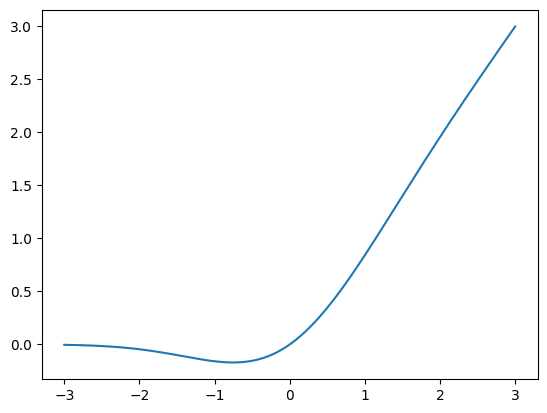

In [17]:
x_axis = torch.linspace(-3, 3, 1000)
gelu = GELU()
y_axis = gelu(x_axis)
plot(x_axis, y_axis)

## Feed Forward Neural Network

In [18]:
class FeedForward(nn.Module):
    
    def __init__(self, cfg):
        super().__init__()
        self.layer1 = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"])
        self.gelu = GELU()
        self.layer2 = nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.gelu(x)
        x = self.layer2(x)
        return x

In [19]:
ffnn = FeedForward(GPT)
example = torch.rand(2, 3, 768)
out = ffnn(example)

In [20]:
print(f'Output shape {out.shape}')
print(f'Output {out}')

Output shape torch.Size([2, 3, 768])
Output tensor([[[-0.0523, -0.0400,  0.1302,  ..., -0.2502, -0.0941,  0.1351],
         [-0.1323,  0.0438,  0.1340,  ..., -0.0537, -0.0199,  0.0819],
         [-0.1274,  0.0838,  0.1423,  ..., -0.1535, -0.0109,  0.0943]],

        [[-0.0166,  0.0620,  0.1343,  ..., -0.1457, -0.0423,  0.1062],
         [-0.1382,  0.0280,  0.2277,  ..., -0.1753,  0.0038,  0.0580],
         [-0.0683,  0.1350,  0.2361,  ..., -0.1892, -0.0060,  0.0377]]],
       grad_fn=<ViewBackward0>)


## Transformer Block

In [21]:
class TransformerBlock(nn.Module):
    
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(cfg["emb_dim"], cfg["emb_dim"], cfg["context_length"], cfg["drop_rate"], cfg["n_heads"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [22]:
block = TransformerBlock(GPT)
output = block(x)

In [23]:
print(f'Input shape: {x.shape}')
print(f'Input: {x}')

Input shape: torch.Size([2, 4, 768])
Input: tensor([[[0.3942, 0.0797, 0.0388,  ..., 0.7325, 0.5751, 0.1967],
         [0.4582, 0.1034, 0.1601,  ..., 0.0048, 0.1978, 0.7837],
         [0.4497, 0.5780, 0.6323,  ..., 0.7156, 0.5417, 0.6435],
         [0.3852, 0.8656, 0.6933,  ..., 0.6622, 0.6614, 0.2047]],

        [[0.6520, 0.9680, 0.4294,  ..., 0.7760, 0.3775, 0.9320],
         [0.3847, 0.0986, 0.0710,  ..., 0.9889, 0.4227, 0.4892],
         [0.4897, 0.1059, 0.1989,  ..., 0.3422, 0.1594, 0.7474],
         [0.4849, 0.2010, 0.3899,  ..., 0.2798, 0.3737, 0.3349]]])


In [24]:
print(f'Output shape: {output.shape}')
print(f'Output: {output}')

Output shape: torch.Size([2, 4, 768])
Output: tensor([[[-2.5272e-01, -1.5723e+00,  4.4762e-01,  ...,  3.5654e-01,
           1.0985e+00, -1.9017e-01],
         [-2.5659e-02, -3.5789e-01,  8.9610e-01,  ..., -3.6992e-01,
           4.9199e-02,  8.0871e-01],
         [ 2.4776e-01, -8.7949e-02,  1.2344e+00,  ..., -4.5320e-01,
           3.3000e-01,  9.0268e-01],
         [ 6.3794e-01,  5.3963e-02,  1.6839e+00,  ...,  9.5100e-02,
           6.2930e-01,  7.8343e-01]],

        [[ 9.9710e-01,  1.5957e+00, -5.9840e-01,  ...,  7.0591e-01,
           1.1954e-01,  3.5345e-01],
         [ 3.8471e-01,  3.6046e-01, -2.8386e-01,  ...,  1.1062e+00,
           4.1209e-01,  4.7460e-01],
         [ 3.6660e-01,  2.5777e-01, -5.1826e-02,  ...,  2.8602e-01,
           2.3695e-03,  1.0237e+00],
         [ 6.3453e-01, -1.5216e-03,  1.7359e-01,  ...,  2.5650e-01,
           7.6697e-02,  6.7885e-01]]], grad_fn=<AddBackward0>)


## GPT-2 Buinding Blocks

In [25]:
class GPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [26]:
inputs = torch.tensor([6109, 3626, 6100, 345])
batch = torch.stack((inputs, inputs), dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 3626, 6100,  345]])


In [27]:
gpt = GPTModel(GPT)
output = gpt(batch)

In [28]:
print(f'Input shape: {x.shape}')
print(f'Input: {x}')

Input shape: torch.Size([2, 4, 768])
Input: tensor([[[0.3942, 0.0797, 0.0388,  ..., 0.7325, 0.5751, 0.1967],
         [0.4582, 0.1034, 0.1601,  ..., 0.0048, 0.1978, 0.7837],
         [0.4497, 0.5780, 0.6323,  ..., 0.7156, 0.5417, 0.6435],
         [0.3852, 0.8656, 0.6933,  ..., 0.6622, 0.6614, 0.2047]],

        [[0.6520, 0.9680, 0.4294,  ..., 0.7760, 0.3775, 0.9320],
         [0.3847, 0.0986, 0.0710,  ..., 0.9889, 0.4227, 0.4892],
         [0.4897, 0.1059, 0.1989,  ..., 0.3422, 0.1594, 0.7474],
         [0.4849, 0.2010, 0.3899,  ..., 0.2798, 0.3737, 0.3349]]])


In [29]:
print(f'Output shape: {output.shape}')
print(f'Output: {output}')

Output shape: torch.Size([2, 4, 50257])
Output: tensor([[[ 0.4595, -1.8174,  0.0547,  ..., -0.0970, -0.7271,  0.1036],
         [ 0.2925, -0.2618,  1.0681,  ..., -0.0799, -0.1556, -0.2260],
         [ 0.1843, -0.8574,  0.3087,  ...,  0.6411,  0.1989, -0.5193],
         [-0.8487,  0.0225, -0.0101,  ...,  0.1125, -0.3541, -0.2174]],

        [[-0.2209, -1.2761, -0.1100,  ..., -0.1365,  0.0346, -0.1011],
         [-0.0879,  0.1843,  1.0082,  ...,  0.0143,  0.2440, -0.7972],
         [-0.1993, -0.9879,  0.8486,  ...,  0.1856,  0.2945, -0.8811],
         [-0.2688, -0.3874,  0.6046,  ...,  0.0205,  0.3209, -0.3815]]],
       grad_fn=<UnsafeViewBackward0>)


## GPT-2 Tokenizer

In [30]:
import tiktoken

In [31]:
tokenizer = tiktoken.get_encoding('gpt2')

In [32]:
txt1 = 'Every effort moves you'
txt2 = 'Every day holds a'

In [33]:
batch = []
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

In [34]:
print('Batch shape:', batch.shape)
print(batch)

Batch shape: torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## Running for a batch

In [35]:
dummy = GPTModel(GPT)
batch = batch
logits = dummy(batch)

In [36]:
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1301, -0.5046, -0.4413,  ..., -0.0362,  0.5217, -0.4158],
         [ 0.3496,  0.1130, -0.4250,  ...,  1.0762,  0.6523,  0.6028],
         [-0.4049,  0.1843,  0.1765,  ...,  1.0201,  0.0375,  0.1313],
         [-0.5452, -0.3952, -0.1033,  ..., -0.1168,  0.3687, -0.2773]],

        [[ 0.0723, -0.5224, -0.1982,  ..., -0.6352,  0.1873,  0.4172],
         [ 0.5576,  0.2400, -0.2722,  ...,  0.1618,  0.1422,  0.8854],
         [ 0.3635, -0.4268,  1.1629,  ..., -0.0825,  0.1050,  0.5049],
         [-0.2233,  0.0667,  0.0988,  ..., -0.5239,  0.8209, -0.3868]]],
       grad_fn=<UnsafeViewBackward0>)


In [37]:
probas = torch.softmax(logits[:, -1, :], dim=-1)
print('Probabilities shape:', probas.shape)
print(probas)

Probabilities shape: torch.Size([2, 50257])
tensor([[9.7384e-06, 1.1314e-05, 1.5149e-05,  ..., 1.4947e-05, 2.4288e-05,
         1.2730e-05],
        [1.3477e-05, 1.8010e-05, 1.8599e-05,  ..., 9.9780e-06, 3.8289e-05,
         1.1444e-05]], grad_fn=<SoftmaxBackward0>)


## Greedy Decoding

In [38]:
next_token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print('Next token ids:', next_token_ids)

Next token ids: tensor([[26670],
        [31307]])


In [39]:
print('Next token:', tokenizer.decode(next_token_ids.tolist()[0]))
print('Next token:', tokenizer.decode(next_token_ids.tolist()[1]))

Next token:  Mesa
Next token:  resilience


### Multinomial

In [40]:
next_token_ids = torch.multinomial(probas, num_samples=1)
print('Next token ids:', next_token_ids)

Next token ids: tensor([[45513],
        [15798]])


In [41]:
print('Next token:', tokenizer.decode(next_token_ids.tolist()[0]))
print('Next token:', tokenizer.decode(next_token_ids.tolist()[1]))

Next token:  Gabe
Next token: Install


### Temperature

In [42]:
temp = 5.0
logits_norm = logits / temp

In [43]:
probas_norm = torch.softmax(logits_norm[:, -1, :], dim=-1)

In [44]:
next_token_ids = torch.multinomial(probas_norm, num_samples=1)
print('Next token ids:', next_token_ids)

Next token ids: tensor([[29132],
        [20482]])


In [45]:
print('Next token:', tokenizer.decode(next_token_ids.tolist()[0]))
print('Next token:', tokenizer.decode(next_token_ids.tolist()[1]))

Next token: KN
Next token: anting


### Top-k

In [46]:
top_k = 3
top_logits, top_pos = torch.topk(logits[:, -1, :][0], top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([2.3373, 2.3102, 2.2948], grad_fn=<TopkBackward0>)
Top positions: tensor([26670, 31250, 26373])


In [47]:
new_logits = torch.where(
    condition=logits[:, -1, :][0] < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=logits[:, -1, :][0],
)
print(new_logits)

tensor([-inf, -inf, -inf,  ..., -inf, -inf, -inf], grad_fn=<WhereBackward0>)


In [48]:
topk_probas = torch.softmax(new_logits, dim=0)
print(sum(topk_probas > 0))

tensor(3)


## Loading GPT-2 weights

In [49]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [50]:
model_name = 'gpt2'

In [51]:
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name, pad_token_id=tokenizer.eos_token_id)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

## Texting

In [52]:
sequence = "Is Alan Turing alive?"

In [53]:
inputs = tokenizer.encode(sequence, return_tensors='pt')

In [54]:
outputs = model.generate(inputs, max_length=200, do_sample=True, num_beams=5, no_repeat_ngram_size=2, early_stopping=True)
outputs

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


tensor([[ 3792, 12246, 39141,  6776,    30,   198,   198,   464,  3280,   284,
           428,  1808,   318,   257,   581,  9969,   366,  8505,  1911,   554,
          1109,    11,   612,   318,   645,  4719,   326, 39141,   373,  6776,
           379,   262,   640,   286,   465,  1918,    11,   475,   340,   318,
          1327,   284,   766,   703,   339,   714,   423,   587,  6776,   611,
           339,   550,   407,   587,  2950,   287,   262,  2478,   286,   262,
         39141,  4572,    13,  1002,   428,   318,   262,  1339,    11,   788,
         39141,   338,  1918,  1276,   423,  5091,   379,   257,   640,   618,
           339,   373,   319,   262, 27373,   286,  5033,   262,   717,  1048,
           284,   307,  8018,   355,   257, 15632,   416,   262,   995,    13,
           554,   584,  2456,    11,   340,  1276,   307,  1744,   329, 39141,
           284,   423,  3724,   379,   597,   640,   287,   465,  1204,    13,
           632,   318,   635,  1744,   326,   339,  

In [55]:
text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(text)

Is Alan Turing alive?

The answer to this question is a resounding "yes". In fact, there is no doubt that Turing was alive at the time of his death, but it is hard to see how he could have been alive if he had not been involved in the development of the Turing machine. If this is the case, then Turing's death must have occurred at a time when he was on the verge of becoming the first person to be recognized as a genius by the world. In other words, it must be possible for Turing to have died at any time in his life. It is also possible that he did not die at all because of a lack of interest in science, or simply because he didn't want to die. However, this does not mean that there was no need for him to do so. He was simply too young to know how to deal with the problems of life and death in general, and he would not have had a chance to learn about them in
